# Sentiment Analysis with BERT

## Task 1.2 — Transformer-Based Model

In this notebook, we implement a Transformer-based sentiment classifier using BERT.

We train and evaluate the model on three different datasets:
- 1K Amazon Reviews
- 25K Amazon Reviews
- Video Game Reviews

Each dataset is processed and evaluated independently using the same pipeline.
This ensures a fair comparison across models in Task 1.3.

In [1]:
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from pathlib import Path

from transformers import AutoTokenizer, AutoModelForSequenceClassification

from utils import device_check
from utils_BERT import (
    build_bert_loaders,
    fit_bert,
    evaluate_bert,
    plot_confusion_matrix_bert,
)

## Setup

In [2]:
LOG_WANDB = True
NUM_WORKERS = 8
PIN_MEMORY = True
SEED = 1

MODEL_NAME = "bert-base-uncased"
MAX_LENGTH = 128
BATCH_SIZE = 16
NUM_EPOCHS = 5

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = device_check()

SPLITS_DIR = Path("../data/splits")

PyTorch: 2.11.0+cu130 | Python: 3.11.15 | OS: Linux 5.15.0-168-generic
CUDA available: True
GPUs: 1 x NVIDIA GeForce RTX 2080 Ti (11.3 GB)
CUDA: 13.0 | cuDNN: 91900
Using cuda / NVIDIA GeForce RTX 2080 Ti


## Dataset 1 — 1K Amazon Reviews

In [3]:
train_df = pd.read_csv(SPLITS_DIR / "1k_train.csv")
val_df = pd.read_csv(SPLITS_DIR / "1k_val.csv")
test_df = pd.read_csv(SPLITS_DIR / "1k_test.csv")

text_col = "Sentence"
label_col = "Class"

NUM_LABELS = 2
NUM_CLASSES = 2

## Tokenizer and DataLoaders

BERT needs `input_ids` and `attention_mask`, so we tokenize the text before training.

In [4]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

loaders = build_bert_loaders(
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    tokenizer=tokenizer,
    text_col=text_col,
    label_col=label_col,
    max_length=MAX_LENGTH,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

train_loader = loaders["train"]
val_loader = loaders["val"]
test_loader = loaders["test"]

## Model

We use `AutoModelForSequenceClassification` with five labels for binary sentiment classification.

In [5]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
)

model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Training

The model is trained on the training split and validated after every epoch.
The best checkpoint is restored automatically.

In [6]:
history_1k = fit_bert(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    num_epochs=NUM_EPOCHS,
    wandb_kwargs={"project": "bert-1k", "name": "bert-1k"},
    log=LOG_WANDB,
)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: hamid-sabeti (d7047e-group12) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch 1/5 | train loss 0.4683, train acc 78.52% | val loss 0.2536, val acc 90.00%
Epoch 2/5 | train loss 0.1569, train acc 95.31% | val loss 0.1311, val acc 96.67%
Epoch 3/5 | train loss 0.0586, train acc 98.52% | val loss 0.2595, val acc 92.22%
Epoch 4/5 | train loss 0.0378, train acc 99.26% | val loss 0.2590, val acc 92.22%
Epoch 5/5 | train loss 0.0120, train acc 99.88% | val loss 0.1932, val acc 95.56%


Training Accuracy,▁▇███
Training Loss,█▃▂▁▁
Validation Accuracy,▁█▃▃▇
Validation Loss,█▁██▄
Training Accuracy,99.87654
Training Loss,0.01202
Validation Accuracy,95.55556
Validation Loss,0.19322



Restored best weights (val loss 0.1311)


## Final Test Evaluation and Confusion Matrix

The final result is reported on the held-out test set for fair comparison with the ANN and LSTM models.



This helps visualize which classes are being predicted correctly and which ones are confused.

[BERT-1K] Test loss: 0.1305 | Test acc: 96.00%


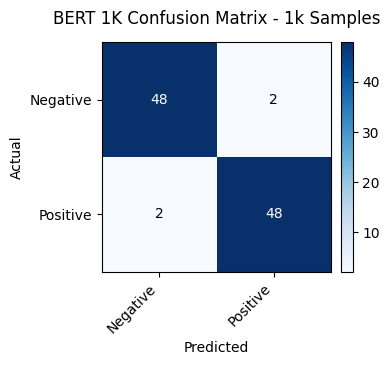

In [7]:
evaluate_bert(model, test_loader, criterion, device, label="BERT-1K")

plot_confusion_matrix_bert(
    model,
    test_loader,
    NUM_CLASSES,
    device,
    ["Negative", "Positive"],
    "BERT 1K Confusion Matrix - 1k Samples",
)

## Dataset 2 — 25K Amazon Reviews

In [8]:
train_df = pd.read_csv(SPLITS_DIR / "25k_train.csv")
val_df = pd.read_csv(SPLITS_DIR / "25k_val.csv")
test_df = pd.read_csv(SPLITS_DIR / "25k_test.csv")

text_col = "Sentence"
label_col = "Class"

NUM_LABELS = 2
NUM_CLASSES = 2

## Tokenizer and DataLoaders


In [9]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

loaders = build_bert_loaders(
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    tokenizer=tokenizer,
    text_col=text_col,
    label_col=label_col,
    max_length=MAX_LENGTH,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

train_loader = loaders["train"]
val_loader = loaders["val"]
test_loader = loaders["test"]

## Model


In [10]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
)

model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Training


In [11]:
history_25k = fit_bert(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    num_epochs=NUM_EPOCHS,
    wandb_kwargs={"project": "bert-25k", "name": "bert-25k"},
    log=LOG_WANDB,
)

Epoch 1/5 | train loss 0.2292, train acc 90.91% | val loss 0.1855, val acc 93.51%
Epoch 2/5 | train loss 0.1230, train acc 95.73% | val loss 0.1755, val acc 93.29%
Epoch 3/5 | train loss 0.0699, train acc 97.95% | val loss 0.3112, val acc 92.27%
Epoch 4/5 | train loss 0.0471, train acc 98.55% | val loss 0.2300, val acc 93.42%
Epoch 5/5 | train loss 0.0312, train acc 99.05% | val loss 0.2793, val acc 93.47%


Training Accuracy,▁▅▇██
Training Loss,█▄▂▂▁
Validation Accuracy,█▇▁██
Validation Loss,▂▁█▄▆
Training Accuracy,99.05185
Training Loss,0.03122
Validation Accuracy,93.46667
Validation Loss,0.27929



Restored best weights (val loss 0.1755)


## Final Test Evaluation and Confusion Matrix

[BERT-25K] Test loss: 0.1874 | Test acc: 93.44%


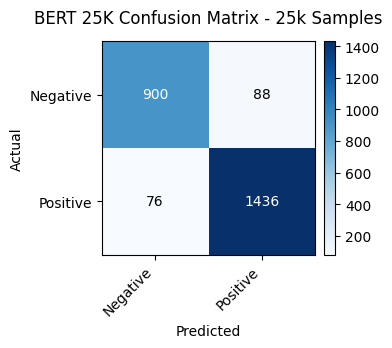

In [12]:
evaluate_bert(model, test_loader, criterion, device, label="BERT-25K")

plot_confusion_matrix_bert(
    model,
    test_loader,
    NUM_CLASSES,
    device,
    ["Negative", "Positive"],
    "BERT Confusion Matrix - 25K Samples",
)

## Dataset 3 — Video Game Reviews

In [13]:
train_df = pd.read_csv(SPLITS_DIR / "vg_train.csv")
val_df = pd.read_csv(SPLITS_DIR / "vg_val.csv")
test_df = pd.read_csv(SPLITS_DIR / "vg_test.csv")

text_col = "Sentence"
label_col = "Class"

# Remap star ratings 1-5 -> 0-4
train_df[label_col] = train_df[label_col].astype(int) - 1
val_df[label_col] = val_df[label_col].astype(int) - 1
test_df[label_col] = test_df[label_col].astype(int) - 1

NUM_LABELS = 5
NUM_CLASSES = 5

## Tokenizer and DataLoaders


In [14]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

loaders = build_bert_loaders(
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    tokenizer=tokenizer,
    text_col=text_col,
    label_col=label_col,
    max_length=MAX_LENGTH,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

train_loader = loaders["train"]
val_loader = loaders["val"]
test_loader = loaders["test"]

## Model

In [15]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
)

model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Training


In [ ]:
history_vg = fit_bert(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    num_epochs=NUM_EPOCHS,
    wandb_kwargs={"project": "bert-vg", "name": "bert-vg"},
    log=LOG_WANDB,
)

wandb: WARNING Fatal error while uploading data. Some run data will not be synced, but it will still be written to disk. Use `wandb sync` at the end of the run to try uploading.


## Final Test Evaluation and Confusion Matrix

In [ ]:
evaluate_bert(model, test_loader, criterion, device, label="BERT-VG")

plot_confusion_matrix_bert(
    model,
    test_loader,
    NUM_CLASSES,
    device,
    ["1", "2", "3", "4", "5"],
    "BERT Confusion Matrix - Video Game Reviews",
)